In [1]:
from pepnets.PeptideNetwork import PeptideNetwork
import random
import pandas as pd
import numpy as np
from pepnets.util import get_database
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

sus_scrofa = pd.read_csv("../data/sus_scrofa.gz", sep="\t")
sus_scrofa["Entry Name"] = sus_scrofa["Entry Name"].apply(lambda x: x.split("_")[0])
database_dict = get_database(sus_scrofa, key_col="Entry Name", value_col="Sequence")

datamatrix = pd.read_csv("../data/data.csv")

pnet = PeptideNetwork(
    datamatrix=datamatrix,
    protein_database=database_dict,
)

/Users/erikhartman/dev/peptide-networks/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reading peptides...


In [2]:
_ = pnet.create_network(distance_cutoff=4)
resolution = 0.8

clusters = pnet.get_clusters(resolution=resolution, random_seed=42)
clusters.merge_nearby_clusters(wiggle_room=2)
clusters.remove_small_clusters(threshold=3)
clusters.reindex()
mapping = clusters.get_mapping(database_dict)

Merged 41 clusters

Removed 0 clusters
Removed 857 clusters
Removed 303 clusters


In [3]:
from pepnets.FeatureMatrix import FeatureMatrix

design = pd.read_csv("../data/design_w_accidental.csv")
fm = FeatureMatrix(pnet.datamatrix, design, clusters)
datamatrix = fm.datamatrix
datamatrix = datamatrix.dropna(subset=["Start"])

nopython is set for njit and is ignored


In [4]:
from pepnets.LogoPlot import LogoPlot

lp = LogoPlot(datamatrix, database_dict, entity="Cluster")

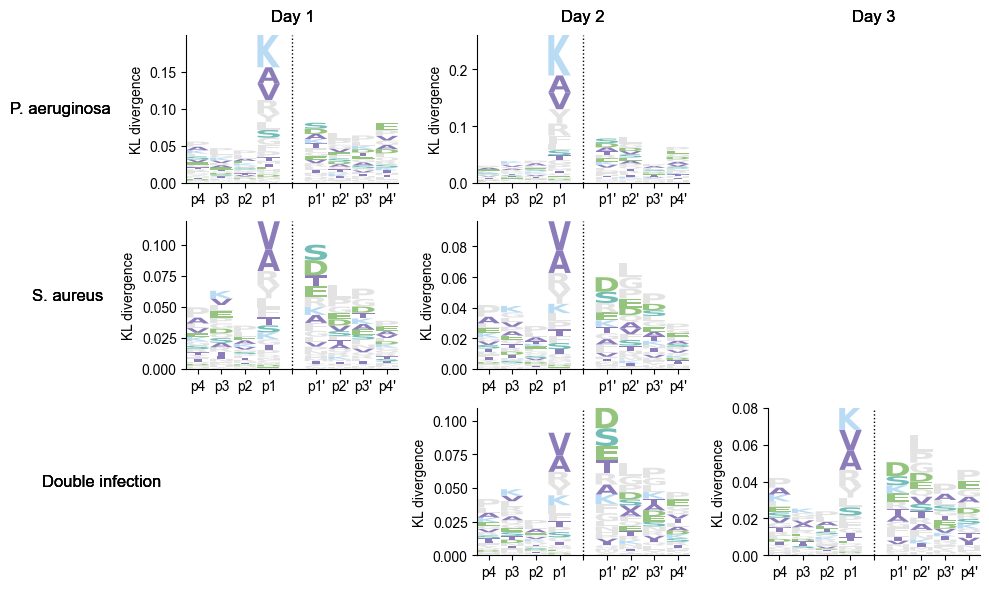

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

groups = [
    "P. aeruginosa",
    "S. aureus",
    "Double infection",
]
positions = ["p4", "p3", "p2", "p1", " ", "p1'", "p2'", "p3'", "p4'"]
max_y = 0
background_samples = design[design["group"] == "Ctrl"]["sample"].tolist()
days = ["Day 1", "Day 2", "Day 3"]
heights = []
fig, axs = plt.subplots(len(groups), len(days), figsize=(10, 6))
for d, day in enumerate(days):
    design_day = design[design["day"] == day]

    for i, test_group in enumerate(groups):
        test_samples = design_day[design_day["group"] == test_group]["sample"].tolist()
        if len(test_samples) == 0:
            axs[i, d].set_xticks([])
            axs[i, d].set_yticks([])
            sns.despine(ax=axs[i, d], left=True, right=True, top=True, bottom=True)
            continue
        height = lp.get_letter_heights(test_samples, background_samples)

        xticks = height.index
        heights.append(height)
        lp.plot(height, ax=axs[i, d])
        sns.despine(ax=axs[i, d])
        axs[i, d].axvline(0, color="k", linewidth=1, linestyle=":")
        axs[i, d].set_ylabel("KL divergence")
        axs[i, d].set_xticks(list(range(-4, 5)), positions)

    for ax in axs.ravel():
        continue

    for ax, col in zip(axs[0], days):
        ax.annotate(
            col,
            xy=(0.5, 1),
            xytext=(0, 10),
            xycoords="axes fraction",
            textcoords="offset points",
            size="large",
            ha="center",
            va="baseline",
        )

    for ax, row in zip(axs[:, 0], groups):
        ax.annotate(
            row,
            xy=(0, 0.5),
            xytext=(-ax.yaxis.labelpad - 10, 0),
            xycoords=ax.yaxis.label,
            textcoords="offset points",
            size="large",
            ha="right",
            va="center",
        )

plt.tight_layout()
pd.concat(heights).to_csv("source_data/3e.csv")
plt.savefig("figures/main_figures/3e.svg", bbox_inches="tight")

In [6]:
import numpy as np

X = {}
test_samples = [
    str(x)
    for x in design[
        design["group"].isin(["S. aureus", "P. aeruginosa", "Double infection"])
    ]["sample"]
]
for i, sample in enumerate(test_samples):
    sample = [str(sample)]
    print(sample)
    height = lp.get_letter_heights(sample, background_samples)
    X[sample[0]] = np.reshape(height.values, (height.shape[0] * height.shape[1],))

['Sample 1 Day 1']
['Sample 2 Day 1']
['Sample 3 Day 1']
['Sample 4 Day 1']
['Sample 5 Day 1']
['Sample 10 Day 1']
['Sample 11 Day 1']
['Sample 12 Day 1']
['Sample 13 Day 1']
['Sample 14 Day 1']
['Sample 15 Day 1']
['Sample 16 Day 1']
['Sample 17 Day 1']
['Sample 18 Day 1']
['Sample 19 Day 1']
['Sample 20 Day 1']
['Sample 21 Day 1']
['Sample 22 Day 1']
['Sample 23 Day 1']
['Sample 24 Day 1']
['Sample 25 Day 1']
['Sample 26 Day 1']
['Sample 27 Day 1']
['Sample 28 Day 1']
['Sample 29 Day 1']
['Sample 30 Day 1']
['Sample 31 Day 1']
['Sample 32 Day 1']
['Sample 33 Day 1']
['Sample 54 Day 1']
['Sample 55 Day 1']
['Sample 56 Day 1']
['Sample 57 Day 1']
['Sample 66 Day 1']
['Sample 67 Day 1']
['Sample 68 Day 1']
['Sample 69 Day 1']
['Sample 70 Day 1']
['Sample 1 Day 2']
['Sample 2 Day 2']
['Sample 3 Day 2']
['Sample 4 Day 2']
['Sample 5 Day 2']
['Sample 10 Day 2']
['Sample 11 Day 2']
['Sample 12 Day 2']
['Sample 13 Day 2']
['Sample 14 Day 2']
['Sample 15 Day 2']
['Sample 16 Day 2']
['Sample 1

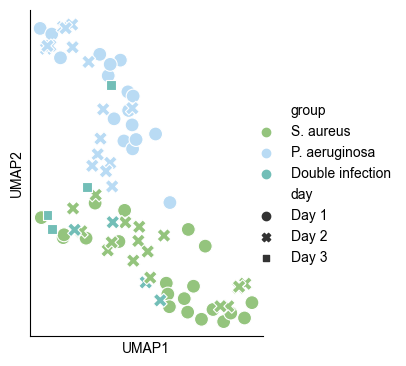

In [14]:
from umap import UMAP
from pepnets.palette import group_palette

p = pd.DataFrame(X)
X_reduced = UMAP(n_components=2).fit_transform(p.T)
plot_df = pd.DataFrame(X_reduced, columns=["UMAP1", "UMAP2"])
design_loc = design.set_index("sample").loc[p.columns]

plot_df = pd.DataFrame(X_reduced, columns=["UMAP1", "UMAP2"])
plot_df["group"] = design_loc.reset_index()["group"]
plot_df["day"] = design_loc.reset_index()["day"]
plot_df["sample"] = design_loc.reset_index(names="sample")["sample"].apply(
    lambda x: x.split(" ")[-1]
)

plot_df.to_csv("source_data/3d.csv")

fig = plt.figure(figsize=(3,4))
sns.scatterplot(
    plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="group",
    s=100,
    style="day",
    palette=group_palette,
)
plt.tight_layout()
plt.legend(loc="upper left", frameon=False, bbox_to_anchor=(0.9, 0.75))
sns.despine()
plt.xticks([])
plt.yticks([])

plt.savefig("figures/main_figures/3d.svg", bbox_inches="tight")

Boolean Series key will be reindexed to match DataFrame index.
Boolean Series key will be reindexed to match DataFrame index.


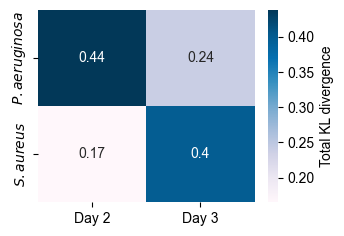

In [5]:
import seaborn as sns


def get_div(design, background_group, test_group):
    divs = []
    background_samples = design[design["day"].isin(["Day 1", "Day 2"])][
        design["group"] == background_group
    ]["sample"].tolist()
    days = ["Day 2", "Day 3"]
    for day in days:
        design_day = design[design["day"] == day]
        test_samples = design_day[design_day["group"] == test_group]["sample"].tolist()

        height = lp.get_letter_heights(test_samples, background_samples)
        divs.append(height.sum(axis=1).sum())
    return divs


pa_divs = get_div(
    design,
    background_group="P. aeruginosa",
    test_group="Double infection",
)
sa_divs = get_div(
    design, background_group="S. aureus", test_group="Double infection"
)
divs = pd.DataFrame(
    [pa_divs, sa_divs],
    index=[r"$P. aeruginosa$", r"$S. aureus$"],
    columns=["Day 2", "Day 3"],
)
plt.figure(figsize=(3.5, 2.5))
sns.heatmap(
    divs,
    annot=True,
    cmap="PuBu",
    cbar_kws={"label": "Total KL divergence"},
)
divs.to_csv("source_data/3h.csv")
plt.savefig("figures/main_figures/3h.svg", bbox_inches="tight")

Mean of empty slice


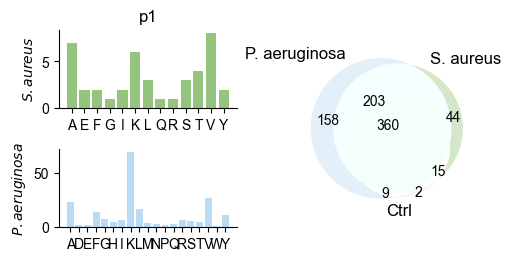

In [9]:
from matplotlib_venn import venn3

topn = topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)
topn = topn[design["sample"]].fillna(0)
days = ["Day 1", "Day 2"]

groups = ["P. aeruginosa", "S. aureus", "Ctrl"]

design_day = design[design["day"].isin(days)]

venn_dict = {}

all_clusters = pd.read_csv("../data/clusters/all_clusters_pig.tsv", sep="\t")

for group in groups:
    group_values = topn[design_day[design_day["group"] == group]["sample"]].T

    means = group_values.mean(axis=0)
    means = means[means > 0]
    venn_dict[group] = set(means.index.values.tolist())

fig, axs = plt.subplot_mosaic(
    [
        [
            "upper left",
            "right",
        ],
        [
            "lower left",
            "right",
        ],
    ],
    figsize=(5,2.5),
    layout="constrained",
)

venn3(
    venn_dict.values(),
    venn_dict.keys(),
    set_colors=[group_palette[group] for group in groups],
    ax=axs["right"],
)

counts = []
for ax, group in zip(
    [axs["upper left"], axs["lower left"]], ["S. aureus", "P. aeruginosa"]
):
    pa = venn_dict[group].copy()
    testing = groups.copy()
    testing.remove(group)
    for cluster in venn_dict[testing[0]].union(venn_dict[testing[1]]):
        if cluster in pa:
            pa.remove(cluster)
    unique_clusters = all_clusters[all_clusters["ID"].isin(pa)].copy()
    unique_clusters["count"] = 1
    countN = unique_clusters.groupby("Np1").sum(numeric_only=True)["count"]
    countC = unique_clusters.groupby("Cp1").sum(numeric_only=True)["count"]
    count = pd.DataFrame({"C": countC, "N": countN}).fillna(0)
    count["tot"] = count["C"] + count["N"]
    count["spec."] = [group] * len(count.index)
    counts.append(count)
    ax.bar(x=count.index, height=count["tot"], color=group_palette[group])
    sns.despine(ax=ax)


axs["upper left"].set_title("p1")

axs["upper left"].set_ylabel(r"$S. aureus$")
axs["lower left"].set_ylabel(r"$P. aeruginosa$")

pd.concat(counts).to_csv("source_data/3f.csv")
plt.savefig("figures/main_figures/3f.svg", bbox_inches="tight")

Mean of empty slice


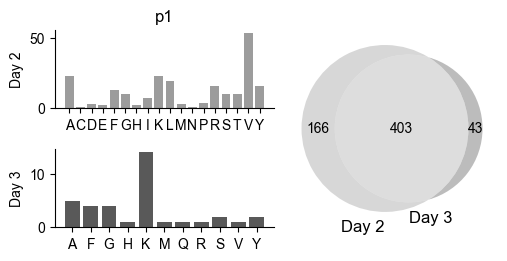

In [10]:
from matplotlib_venn import venn2
from pepnets.palette import day_palette

topn = topn = (
    fm.get_topn()
    .groupby("Cluster")
    .mean(numeric_only=True)
    .drop(columns=["id", "Start", "End"])
)

topn = topn[design["sample"]].fillna(0)
days = ["Day 2", "Day 3"]

groups = ["Double infection"]

design_group = design[design["group"].isin(groups)]

venn_dict = {}

all_clusters = pd.read_csv("../data/clusters/all_clusters_pig.tsv", sep="\t")

for day in days:
    day_values = topn[design_group[design_group["day"] == day]["sample"]].T

    means = day_values.mean(axis=0)
    means = means[means > 0]
    venn_dict[day] = set(means.index.values.tolist())


fig, axs = plt.subplot_mosaic(
    [
        [
            "upper left",
            "right",
        ],
        [
            "lower left",
            "right",
        ],
    ],
    figsize=(5,2.5),
    layout="constrained",
)

venn2(
    venn_dict.values(),
    venn_dict.keys(),
    set_colors=[day_palette[day] for day in days],
    ax=axs["right"],
)


for ax, day in zip([axs["upper left"], axs["lower left"]], ["Day 2", "Day 3"]):
    pa = venn_dict[day].copy()
    testing = days.copy()
    testing.remove(day)
    for cluster in venn_dict[testing[0]]:
        if cluster in pa:
            pa.remove(cluster)

    unique_clusters = all_clusters[all_clusters["ID"].isin(pa)].copy()
    unique_clusters["count"] = 1
    countN = unique_clusters.groupby("Np1").sum(numeric_only=True)["count"]
    countC = unique_clusters.groupby("Cp1").sum(numeric_only=True)["count"]
    count = pd.DataFrame({"C": countC, "N": countN}).fillna(0)
    count["tot"] = count["C"] + count["N"]
    count["day"] = [day] * len(count.index)
    ax.bar(x=count.index, height=count["tot"], color=day_palette[day])
    sns.despine(ax=ax)


axs["upper left"].set_title("p1")

axs["upper left"].set_ylabel("Day 2")
axs["lower left"].set_ylabel("Day 3")
pd.concat(counts).to_csv("source_data/3g.csv")
plt.savefig("figures/main_figures/3g.svg", bbox_inches="tight")